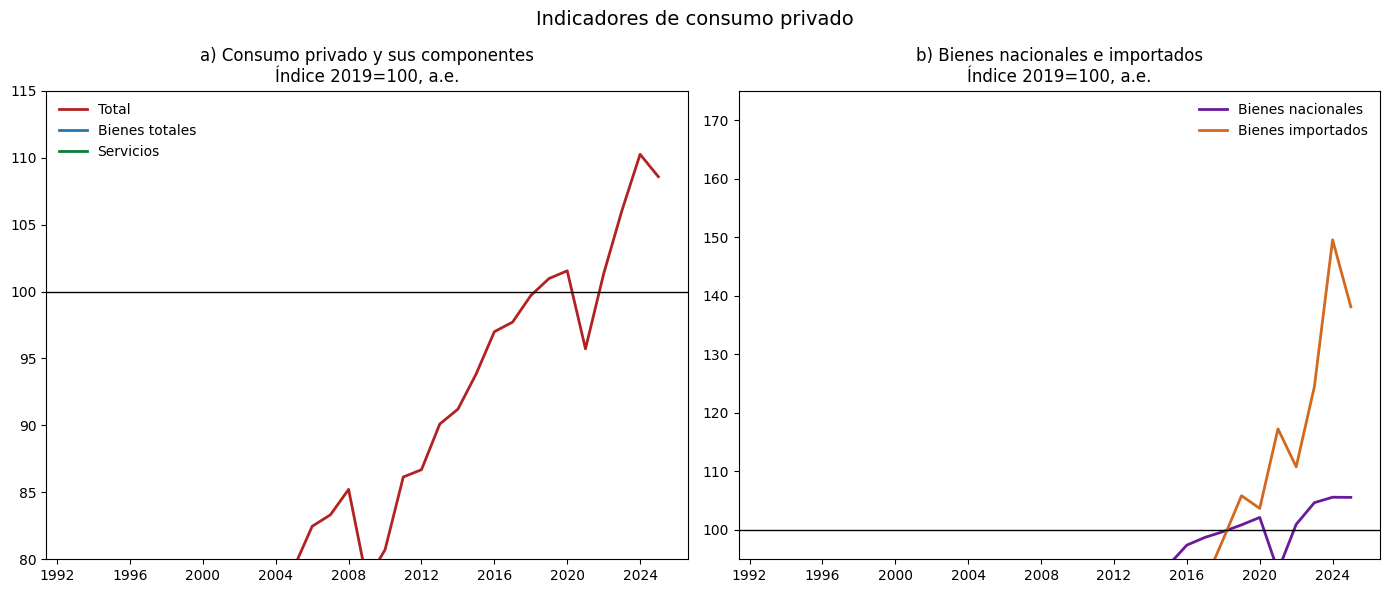

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# CONFIG
# =====================================
PATH = "raw/cp_indice.xlsx"
SHEET = "CP-indice"


MONTH_MAP = {
    "ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,
    "JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12
}

# =====================================
# 1) LEER TODO SIN HEADER
# =====================================
raw = pd.read_excel(PATH, sheet_name=SHEET, header=None)

# -------------------------------------
# localizar fila donde están los meses
# -------------------------------------
month_row = None
for i in range(20):
    row = raw.iloc[i].astype(str).str.upper()
    if row.isin(MONTH_MAP.keys()).sum() >= 6:
        month_row = i
        break

assert month_row is not None, "No encontré fila de meses"

# la fila de arriba trae los años
year_row = month_row - 1

months = raw.iloc[month_row]
years  = raw.iloc[year_row]

# =====================================
# 2) ARMAR COLUMNAS FECHA
# =====================================
dates = []

for m, y in zip(months, years):

    m = str(m).strip().upper()[:3]

    if m not in MONTH_MAP:
        dates.append(None)
        continue

    try:
        y = int(float(y))
    except:
        dates.append(None)
        continue

    dates.append(pd.Timestamp(y, MONTH_MAP[m], 1))

# =====================================
# 3) EXTRAER MATRIZ NUMÉRICA
# =====================================
data = raw.iloc[month_row+1:].copy()

data = data.rename(columns={0: "serie"})
data = data.dropna(subset=["serie"])

# quedarnos solo con columnas válidas
valid_cols = [i for i,d in enumerate(dates) if d is not None]
data = data.iloc[:, [0] + valid_cols]

dates = [dates[i] for i in valid_cols]
data.columns = ["serie"] + dates

# quitar notas
data = data[~data["serie"].astype(str).str.contains("NOTA|FUENTE", case=False)]

# =====================================
# 4) PASAR A LARGO
# =====================================
long = data.melt(id_vars="serie", var_name="date", value_name="value")
long["date"] = pd.to_datetime(long["date"])
long = long.dropna(subset=["value"])

# =====================================
# 5) SACAR SERIES
# =====================================
def get(name):
    return (
        long[long["serie"].str.contains(name, case=False)]
        .set_index("date")
        .sort_index()["value"]
    )

total     = get("^TOTAL$")
bienes    = get("^Bienes$")
servicios = get("Servicios")
nacional  = get("^Nacional$")
importado = get("Importado")

# =====================================
# 6) GRAFICAR
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True)

RED="#b22222"; BLUE="#1f77b4"; GREEN="#0b7d3e"
PURPLE="#6a1b9a"; ORANGE="#d2691e"

# ---- panel a
ax = axes[0]
ax.plot(total, color=RED, lw=2, label="Total")
ax.plot(bienes, color=BLUE, lw=2, label="Bienes totales")
ax.plot(servicios, color=GREEN, lw=2, label="Servicios")
ax.axhline(100, color="black", lw=1)

ax.set_title("a) Consumo privado y sus componentes\nÍndice 2019=100, a.e.")
ax.legend(frameon=False)
ax.set_ylim(80,115)

# ---- panel b
ax = axes[1]
ax.plot(nacional, color=PURPLE, lw=2, label="Bienes nacionales")
ax.plot(importado, color=ORANGE, lw=2, label="Bienes importados")
ax.axhline(100, color="black", lw=1)

ax.set_title("b) Bienes nacionales e importados\nÍndice 2019=100, a.e.")
ax.legend(frameon=False)
ax.set_ylim(95,175)

fig.suptitle("Indicadores de consumo privado", fontsize=14)
plt.tight_layout()
plt.show()


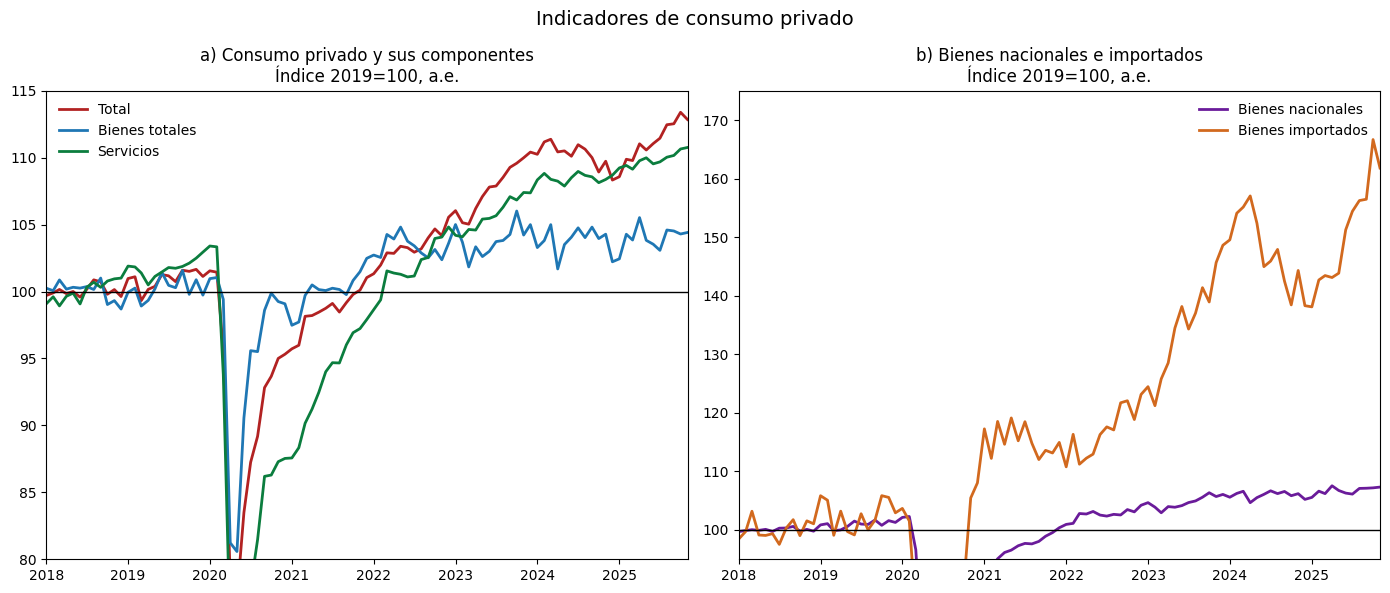

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# =====================================
# CONFIG
# =====================================
PATH  = "raw/cp_indice.xlsx"
SHEET = "CP-indice"
START = "2018-01-01"

MONTH_MAP = {
    "ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,
    "JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12
}

# Colores
RED    = "#b22222"
BLUE   = "#1f77b4"
GREEN  = "#0b7d3e"
PURPLE = "#6a1b9a"
ORANGE = "#d2691e"

# =====================================
# 1) LEER HOJA COMPLETA (sin header)
# =====================================
raw = pd.read_excel(PATH, sheet_name=SHEET, header=None)

# =====================================
# 2) IDENTIFICAR FILA DE MESES (ENE...DIC)
# =====================================
month_row = None
for i in range(80):
    row = raw.iloc[i].astype(str).str.upper().str.strip()
    if row.isin(MONTH_MAP.keys()).sum() >= 6:
        month_row = i
        break
if month_row is None:
    raise ValueError("No encontré la fila de meses (ENE..DIC).")

year_row = month_row - 1

months = raw.iloc[month_row]
years  = raw.iloc[year_row]

# =====================================
# 3) CONSTRUIR FECHAS POR COLUMNA
#    (año aparece en ENE y luego NaN -> fill forward)
# =====================================
dates = []
current_year = None

for m, y in zip(months, years):
    m3 = str(m).strip().upper()[:3]
    if m3 not in MONTH_MAP:
        dates.append(None)
        continue

    # actualizar año si viene
    try:
        if pd.notna(y):
            current_year = int(float(y))
    except:
        pass

    if current_year is None:
        dates.append(None)
        continue

    dates.append(pd.Timestamp(current_year, MONTH_MAP[m3], 1))

valid_idx = [j for j, d in enumerate(dates) if d is not None]
valid_dates = [dates[j] for j in valid_idx]

# =====================================
# 4) ARMAR MATRIZ (series x fechas)
#    Serie = col A si existe; si no, col B
# =====================================
data = raw.iloc[month_row + 1:, :].copy()

def norm(s):
    s = "" if pd.isna(s) else str(s)
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

serie_A = data.iloc[:, 0].map(norm)
serie_B = data.iloc[:, 1].map(norm)
data["serie"] = np.where(serie_A != "", serie_A, serie_B)
data = data[data["serie"] != ""]

# quitar notas/fuente
data = data[~pd.Series(data["serie"]).str.contains("NOTA|FUENTE", case=False, na=False)]

# quedarnos con columnas de meses válidas
mat = data.iloc[:, valid_idx].copy()
mat.columns = valid_dates
mat.insert(0, "serie", data["serie"].values)

# =====================================
# 5) PASAR A LARGO
# =====================================
long = mat.melt(id_vars="serie", var_name="date", value_name="value")
long["date"] = pd.to_datetime(long["date"])
long["value"] = pd.to_numeric(long["value"], errors="coerce")
long = long.dropna(subset=["value"])

# =====================================
# 6) EXTRAER SERIES (exactas, ya normalizadas)
# =====================================
def pick(name_exact):
    s = long[long["serie"].str.lower() == name_exact.lower()].set_index("date").sort_index()["value"]
    return s

total     = pick("TOTAL")
nacional  = pick("Nacional")
bienes    = pick("Bienes")
servicios = pick("Servicios")
importado = pick("Importado")  # en tu archivo puede traer espacios; norm() ya los quitó

# =====================================
# 7) RECORTAR DESDE 2018
# =====================================
total     = total.loc[START:]
nacional  = nacional.loc[START:]
bienes    = bienes.loc[START:]
servicios = servicios.loc[START:]
importado = importado.loc[START:]

# =====================================
# 8) GRAFICAR (2 paneles, ejes desde 2018)
# =====================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Panel a
ax = axes[0]
ax.plot(total.index, total.values, color=RED, lw=2, label="Total")
ax.plot(bienes.index, bienes.values, color=BLUE, lw=2, label="Bienes totales")
ax.plot(servicios.index, servicios.values, color=GREEN, lw=2, label="Servicios")
ax.axhline(100, color="black", lw=1)

ax.set_title("a) Consumo privado y sus componentes\nÍndice 2019=100, a.e.")
ax.legend(frameon=False, loc="upper left")
ax.set_ylim(80, 115)
ax.set_xlim(pd.Timestamp(START), total.index.max())

# Panel b
ax = axes[1]
ax.plot(nacional.index, nacional.values, color=PURPLE, lw=2, label="Bienes nacionales")
ax.plot(importado.index, importado.values, color=ORANGE, lw=2, label="Bienes importados")
ax.axhline(100, color="black", lw=1)

ax.set_title("b) Bienes nacionales e importados\nÍndice 2019=100, a.e.")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(95, 175)
ax.set_xlim(pd.Timestamp(START), importado.index.max())

fig.suptitle("Indicadores de consumo privado", fontsize=14)
plt.tight_layout()
plt.show()


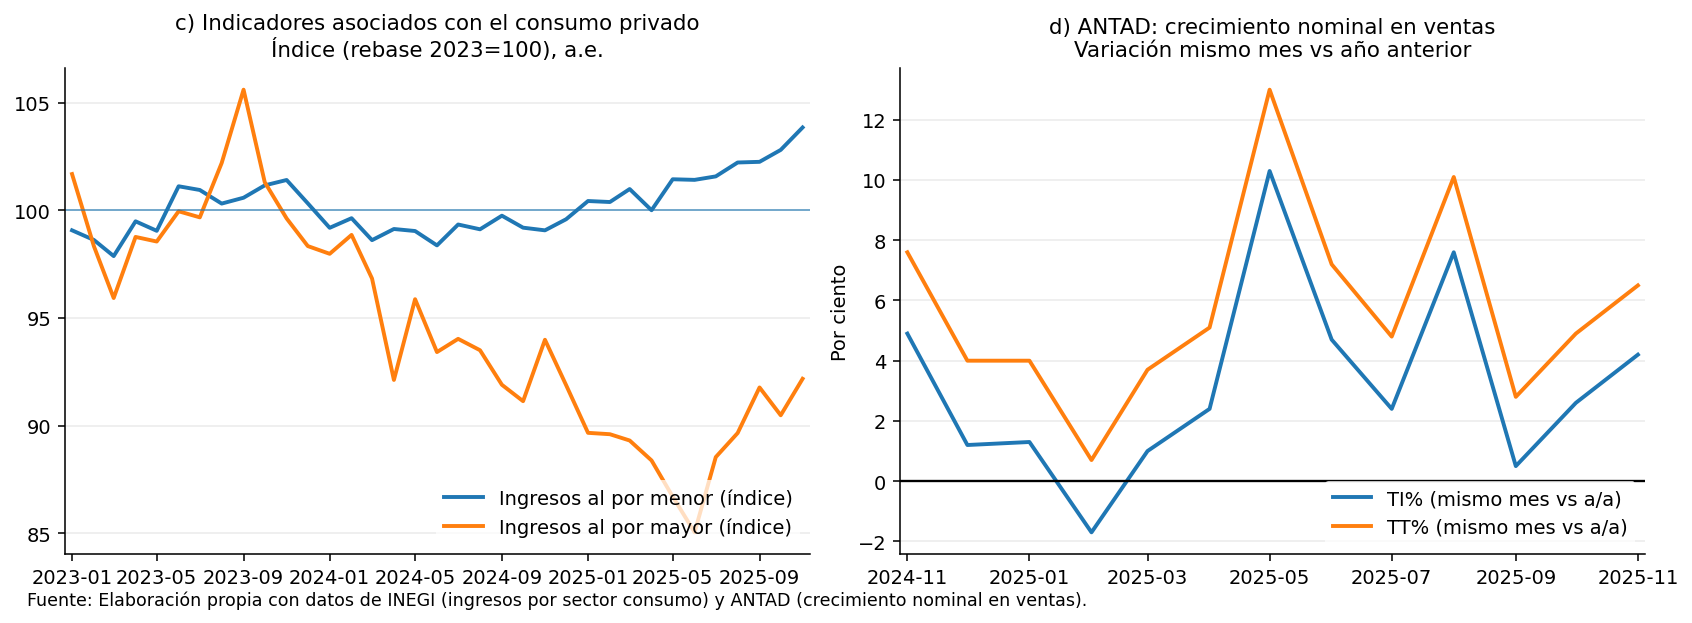

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
PATH_CONSUMO = "raw/ingresos_consumo.csv"   # (ya está montado)
PATH_ANTAD   = "raw/antad.json"                       # pon aquí tu ruta real (ej. "raw/antad.json")

BASE_YEAR_TRY = 2022          # intentamos 2022=100 como en tu figura
START_DATE = "2018-01-01"     # para recortar si aplica (ANTAD, etc.)

# Estilo tipo "reporte"
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

MONTH_MAP_ES = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "setiembre": 9,
    "octubre": 10, "noviembre": 11, "diciembre": 12
}

# ============================================================
# HELPERS
# ============================================================
def clean_spanish_token(x: str) -> str:
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def parse_ingresos_consumo_matrix(path_csv: str) -> pd.DataFrame:
    """
    Convierte el CSV de INEGI que viene así:
      2023
      Enero   ...
      Febrero...
      ...
      2024
      Enero ...
    en un dataframe largo con fecha mensual.
    """
    raw = pd.read_csv(path_csv)
    raw.columns = [c.strip() for c in raw.columns]

    if "Periodo" not in raw.columns:
        raise ValueError("No encontré columna 'Periodo' en ingresos_consumo.csv")

    out = []
    current_year = None

    for _, row in raw.iterrows():
        token = clean_spanish_token(row["Periodo"])

        # fila de año (ej. "2023")
        if token.isdigit() and len(token) == 4:
            current_year = int(token)
            continue

        # fila de mes
        if current_year is None:
            continue

        m = MONTH_MAP_ES.get(token, None)
        if m is None:
            # ignora cualquier cosa rara
            continue

        date = pd.Timestamp(current_year, m, 1)

        record = {"date": date}
        for col in raw.columns:
            if col == "Periodo":
                continue
            record[col] = pd.to_numeric(row[col], errors="coerce")
        out.append(record)

    df = pd.DataFrame(out).sort_values("date").reset_index(drop=True)
    return df

def pct_m_to_index(pct_series: pd.Series, start_level: float = 100.0) -> pd.Series:
    """
    Convierte variación porcentual mensual (m/m) a nivel índice encadenado.
    pct en % (ej 1.2 = 1.2%).
    """
    s = pct_series.astype(float).copy()
    idx = np.full(len(s), np.nan, dtype=float)

    level = start_level
    for i, v in enumerate(s.values):
        if np.isnan(v):
            idx[i] = np.nan
        else:
            level = level * (1.0 + v/100.0)
            idx[i] = level

    return pd.Series(idx, index=s.index)

def rebase_index_to_year(idx: pd.Series, dates: pd.Series, base_year_try: int = 2022) -> tuple[pd.Series, int]:
    """
    Rebasa para que el promedio del año base sea 100.
    Si base_year_try no está en los datos, usa el primer año completo disponible.
    """
    tmp = pd.DataFrame({"date": dates, "idx": idx}).dropna()
    tmp["year"] = tmp["date"].dt.year

    years = sorted(tmp["year"].unique().tolist())
    if base_year_try in years:
        base_year = base_year_try
    else:
        # primer año con >=10 meses disponibles (heurística)
        base_year = None
        for y in years:
            n = (tmp["year"] == y).sum()
            if n >= 10:
                base_year = y
                break
        if base_year is None:
            base_year = years[0]

    base_mean = tmp.loc[tmp["year"] == base_year, "idx"].mean()
    rebased = idx * (100.0 / base_mean)
    return rebased, base_year

def parse_antad_json(path_json: str) -> pd.DataFrame:
    """
    Espera JSON tipo:
    [
      {"year":2024,"month":"Noviembre","ti_pct":4.9,"tt_pct":7.6},
      ...
    ]
    """
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data).copy()

    # normaliza nombres
    for c in ["year","month","ti_pct","tt_pct"]:
        if c not in df.columns:
            raise ValueError(f"En antad.json falta la llave '{c}'")

    df["month_num"] = df["month"].map(lambda x: MONTH_MAP_ES.get(clean_spanish_token(x), np.nan))
    if df["month_num"].isna().any():
        bad = df.loc[df["month_num"].isna(), "month"].unique().tolist()
        raise ValueError(f"Mes(es) no reconocido(s) en antad.json: {bad}")

    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month_num"], day=1))
    df = df.sort_values("date").reset_index(drop=True)

    # recorte opcional
    df = df[df["date"] >= pd.to_datetime(START_DATE)].copy()

    return df[["date","ti_pct","tt_pct"]]

def banxico_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")

def legend_box(ax, loc="lower right"):
    leg = ax.legend(loc=loc, frameon=True, ncol=1)
    frame = leg.get_frame()
    frame.set_alpha(0.75)      # semitransparente
    frame.set_linewidth(0.0)
    return leg

# ============================================================
# 1) CONSUMO: leer + construir índices
# ============================================================
cons = parse_ingresos_consumo_matrix(PATH_CONSUMO)

# columnas disponibles (en tu archivo: "Al por mayor", "Al por menor")
# convertimos cada columna a índice encadenado
idx_cols = [c for c in cons.columns if c != "date"]
for c in idx_cols:
    cons[c + "_idx_raw"] = pct_m_to_index(cons[c], start_level=100.0)

# rebaseo (intenta 2022; si no existe usa primer año completo)
base_used = None
for c in idx_cols:
    rebased, base_year = rebase_index_to_year(cons[c + "_idx_raw"], cons["date"], BASE_YEAR_TRY)
    cons[c + "_idx"] = rebased
    base_used = base_year  # el mismo casi siempre

# ============================================================
# 2) ANTAD: leer json
# ============================================================
antad = parse_antad_json(PATH_ANTAD)

# ============================================================
# 3) FIGURA (2 PANELES): consumo (índices) + antad (YoY)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))

# -------------------------
# Panel (c) - Consumo
# -------------------------
ax = axes[0]
banxico_axes(ax)

# Ajusta qué series quieres graficar (por default ambas si existen)
plot_series = []
if "Al por menor_idx" in cons.columns:
    plot_series.append(("Ingresos al por menor (índice)", "Al por menor_idx"))
if "Al por mayor_idx" in cons.columns:
    plot_series.append(("Ingresos al por mayor (índice)", "Al por mayor_idx"))

for label, col in plot_series:
    ax.plot(cons["date"], cons[col], linewidth=2.0, label=label)

title_base = f"Índice {BASE_YEAR_TRY}=100" if base_used == BASE_YEAR_TRY else f"Índice (rebase {base_used}=100)"
ax.set_title("c) Indicadores asociados con el consumo privado\n" + title_base + ", a.e.")
ax.set_xlabel("")
ax.set_ylabel("")
ax.axhline(100, linewidth=1.0, alpha=0.6)

legend_box(ax, loc="lower right")

# compactar x
ax.margins(x=0.01)

# -------------------------
# Panel (d) - ANTAD (YoY)
# -------------------------
ax = axes[1]
banxico_axes(ax)

# TI% y TT% (variación mismo mes vs año anterior) en la ANTAD
ax.plot(antad["date"], antad["ti_pct"], linewidth=2.0, label="TI% (mismo mes vs a/a)")
ax.plot(antad["date"], antad["tt_pct"], linewidth=2.0, label="TT% (mismo mes vs a/a)")

ax.set_title("d) ANTAD: crecimiento nominal en ventas\nVariación mismo mes vs año anterior")
ax.set_xlabel("")
ax.set_ylabel("Por ciento")

# línea cero como en muchas gráficas
ax.axhline(0, color="black", linewidth=1.2)

legend_box(ax, loc="lower right")
ax.margins(x=0.01)

plt.tight_layout()

# Nota tipo reporte (centrada)
fig.text(
    0.02, 0.005,
    "Fuente: Elaboración propia con datos de INEGI (ingresos por sector consumo) y ANTAD (crecimiento nominal en ventas).",
    ha="left",fontsize=9
)

plt.show()


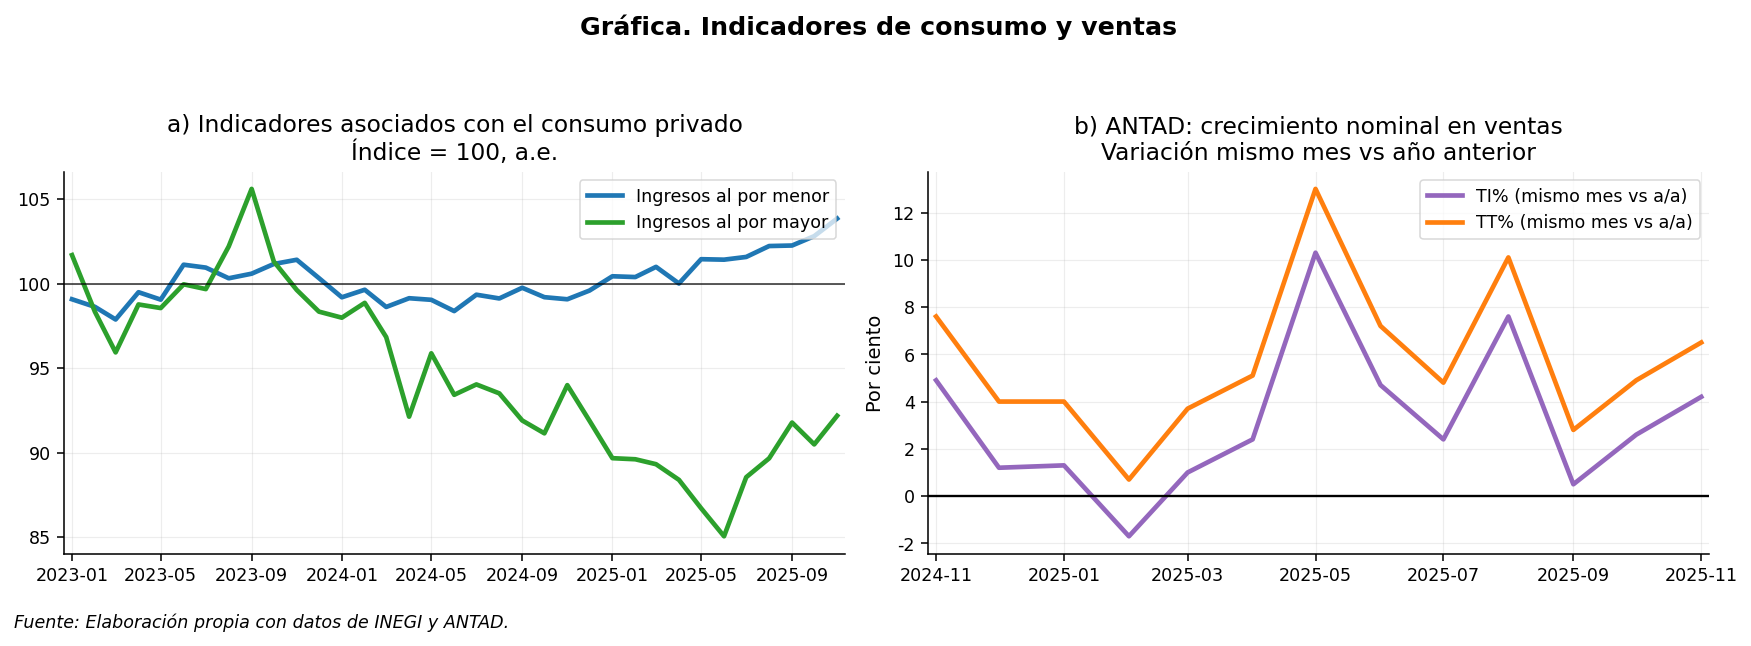

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ESTILO "REPORTE" (como la figura del PIB)
# ============================================================
def set_report_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.unicode_minus": False,
    })

COL = {
    "negro": "#000000",
    "azul":  "#1f77b4",
    "verde": "#2ca02c",
    "morado":"#9467bd",
    "naranja":"#ff7f0e",
    "teal":  "#17becf",
    "vino":  "#8c1d40",
}

def report_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(True, axis="both", alpha=0.22, linewidth=0.6)
    ax.tick_params(length=3.5, width=0.8)

def report_legend(ax, loc="upper right", ncol=1):
    leg = ax.legend(loc=loc, frameon=True, ncol=ncol)
    frame = leg.get_frame()
    frame.set_alpha(0.75)     # 👈 lo que pediste
    frame.set_linewidth(0.8)
    return leg


# ============================================================
# FIGURA: CONSUMO + ANTAD
# (asume que ya tienes: cons y antad)
# ============================================================
set_report_style()

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

# -------------------------
# a) Consumo
# -------------------------
ax = axes[0]
report_axes(ax)

ax.plot(
    cons["date"],
    cons["Al por menor_idx"],
    color=COL["azul"],
    linewidth=2.4,
    label="Ingresos al por menor"
)

ax.plot(
    cons["date"],
    cons["Al por mayor_idx"],
    color=COL["verde"],
    linewidth=2.4,
    label="Ingresos al por mayor"
)

ax.axhline(100, color=COL["negro"], linewidth=1.0, alpha=0.65)

ax.set_title("a) Indicadores asociados con el consumo privado\nÍndice = 100, a.e.")
ax.set_xlabel("")
ax.set_ylabel("")
ax.margins(x=0.01)

report_legend(ax, loc="upper right")

# -------------------------
# b) ANTAD
# -------------------------
ax = axes[1]
report_axes(ax)

ax.plot(
    antad["date"],
    antad["ti_pct"],
    color=COL["morado"],
    linewidth=2.4,
    label="TI% (mismo mes vs a/a)"
)

ax.plot(
    antad["date"],
    antad["tt_pct"],
    color=COL["naranja"],
    linewidth=2.4,
    label="TT% (mismo mes vs a/a)"
)

ax.axhline(0, color=COL["negro"], linewidth=1.2)

ax.set_title("b) ANTAD: crecimiento nominal en ventas\nVariación mismo mes vs año anterior")
ax.set_xlabel("")
ax.set_ylabel("Por ciento")
ax.margins(x=0.01)

report_legend(ax, loc="upper right")

# -------------------------
# TÍTULO GENERAL + NOTA
# -------------------------
fig.suptitle(
    "Gráfica. Indicadores de consumo y ventas",
    y=0.98,
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.01, 0.02,
    "Fuente: Elaboración propia con datos de INEGI y ANTAD.",
    ha="left",
    va="bottom",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()


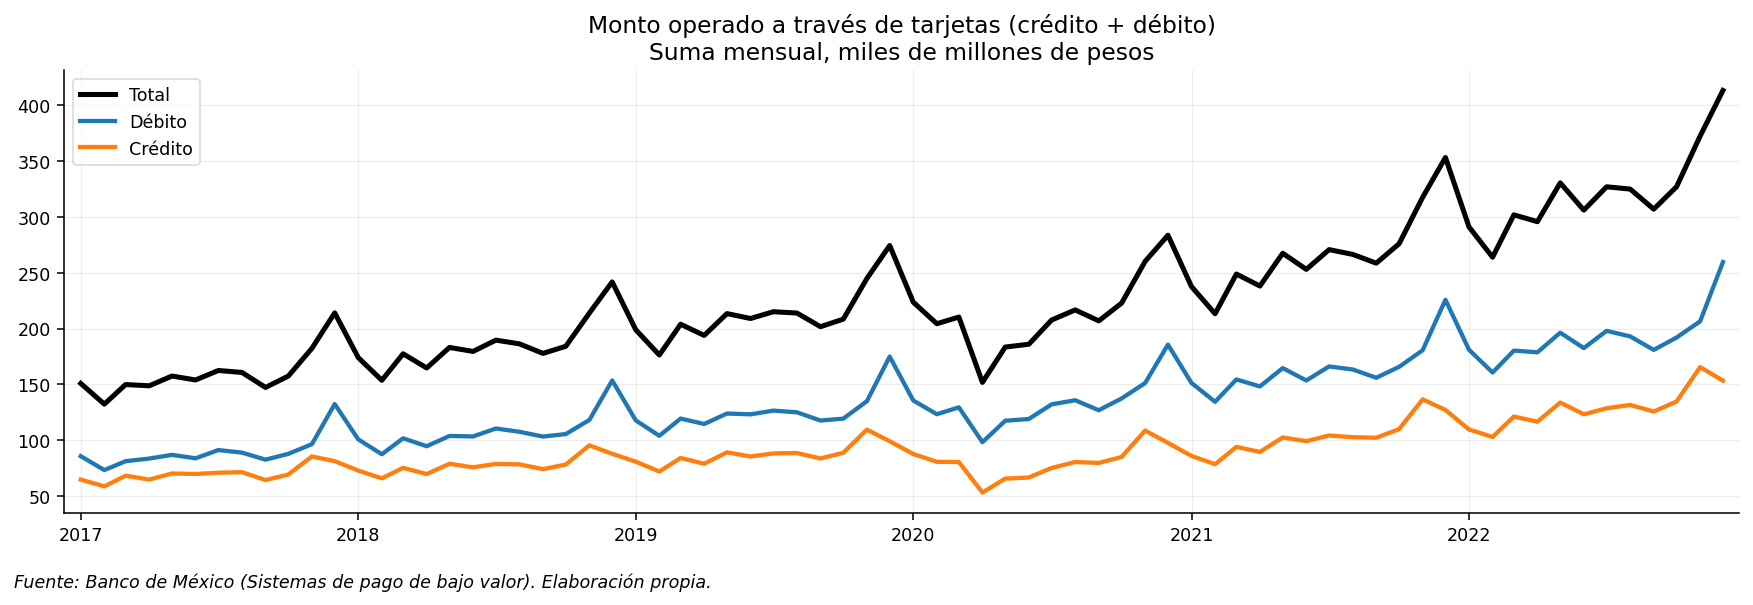

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
PATH_TARJETAS = "raw/tarjetas.csv"   # ya está montado

# ============================================================
# ESTILO (similar a tu figura)
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.unicode_minus": False,
})

COL = {
    "negro": "#000000",
    "azul":  "#1f77b4",
    "naranja":"#ff7f0e",
    "verde": "#2ca02c",
}

def report_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="both", alpha=0.22, linewidth=0.6)
    ax.tick_params(length=3.5, width=0.8)

def report_legend(ax, loc="upper right", ncol=1, alpha=0.75):
    leg = ax.legend(loc=loc, frameon=True, ncol=ncol)
    frame = leg.get_frame()
    frame.set_alpha(alpha)       # 👈 opacidad 0.75
    frame.set_linewidth(0.8)
    return leg

# ============================================================
# 1) LEER TARJETAS (Banxico export con metadata)
# ============================================================
# En tu archivo, la fila 11 (0-based=10) trae el encabezado real
df = pd.read_csv(PATH_TARJETAS, encoding="latin-1", skiprows=10)

# Identifica filas de datos: la primera columna ("Título") tiene fechas dd/mm/yyyy
mask_date = df["Título"].astype(str).str.match(r"\d{2}/\d{2}/\d{4}")
df = df.loc[mask_date].copy()

# Parsea fecha
df["date"] = pd.to_datetime(df["Título"], format="%d/%m/%Y", errors="coerce")

# Columnas principales (exactas en tu archivo)
COL_TOTAL  = "Total de monto operado a través de tarjetas"
COL_DEBITO = "Monto operado a través de tarjetas de débito"
COL_CREDITO= "Monto operado a través de tarjetas de crédito"

for c in [COL_TOTAL, COL_DEBITO, COL_CREDITO]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["date"]).sort_values("date")

# ============================================================
# 2) PASAR DE DIARIO A MENSUAL (suma de flujos)
# ============================================================
m = (
    df.set_index("date")[[COL_TOTAL, COL_DEBITO, COL_CREDITO]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)

# Opcional: expresar en miles de millones de pesos (mdp -> mmdp)
SCALE = 1e9
m["total_mmdp"]  = m[COL_TOTAL]  / SCALE
m["debito_mmdp"] = m[COL_DEBITO] / SCALE
m["credito_mmdp"]= m[COL_CREDITO]/ SCALE

# ============================================================
# 3) GRÁFICA (formato similar, sin puntadas)
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(12.6, 4.6))
report_axes(ax)

ax.plot(m["date"], m["total_mmdp"],  color=COL["negro"],  linewidth=2.6, label="Total")
ax.plot(m["date"], m["debito_mmdp"], color=COL["azul"],   linewidth=2.2, label="Débito")
ax.plot(m["date"], m["credito_mmdp"],color=COL["naranja"],linewidth=2.2, label="Crédito")

ax.set_title("Monto operado a través de tarjetas (crédito + débito)\nSuma mensual, miles de millones de pesos")
ax.set_xlabel("")
ax.set_ylabel("")
ax.margins(x=0.01)

report_legend(ax, loc="upper left", alpha=0.75)

fig.text(
    0.01, 0.02,
    "Fuente: Banco de México (Sistemas de pago de bajo valor). Elaboración propia.",
    ha="left", va="bottom", fontsize=9, style="italic"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
